###### Proyecto minería de datos - MIS
##### **Detección de Discurso de Odio en Español Chileno en Twitter**

Importamos todas las librerias que se utilizaran para el desarrollo del proyecto.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Para el desarrollo de este proyecto contamos con 2 dataset que se obtuvieron de manera gratuita desde repositorios de internet.

Abrimos el primer dataset denominado **dataset_chileno_lenguaje_ofensivo**.

In [2]:
df1 = pd.read_csv("dataset_chileno_lenguaje_ofensivo.csv")
df1

,Unnamed: 0,caso,link,tweet a etiquetar,contexto,anónimo,género,mención migración,mención venezuela,mención política nacional,...,mención otros,grosería c/int.,grosería s/int.,insulto/sobrenombre,hate speech/estereotipo,sarcasmo/ironía/burla,pregunta legítima,evidencia,figura femenina,figura masculina
0,0,23036.0,https://twitter.com/labrigidagon/status/140128...,Eran tan pero tan feministas que invisibilizab...,NaN,1.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,23057.0,https://twitter.com/karenseguelr/status/140270...,@Eneatipo7 @Cooperativa @karina_ol Me carga en...,NaN,1.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,NaN,NaN,NaN,@Cooperativa @karina_ol te equivocas.\r\nApoya...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,Karina Oliva: Quienes apoyan a Orrego defiende...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,23058.0,https://twitter.com/patrianueva2020/status/140...,", ¿Sabrán las femiorcas como @karina_ol y todo...",NaN,1.0,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20959,20959,NaN,NaN,NaN,GAMBA y su desilusión con la extrema izquierda...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20960,20960,23027.0,https://twitter.com/arttauro/status/1401383544...,@andreaenlaruta @Clintjoselint entonces las fe...,NaN,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20961,20961,NaN,NaN,NaN,@arttauro @Clintjoselint Gnecco apoya a Brione...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20962,20962,NaN,NaN,NaN,@Clintjoselint no aplica a los miembros de la ...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Eliminamos registros con valores Nulos con respecto a la columna **hate speech/estereotipo**.

In [3]:
df1_limpio = df1.dropna(subset=['hate speech/estereotipo']).reset_index(drop=True)
df1_limpio

,Unnamed: 0,caso,link,tweet a etiquetar,contexto,anónimo,género,mención migración,mención venezuela,mención política nacional,...,mención otros,grosería c/int.,grosería s/int.,insulto/sobrenombre,hate speech/estereotipo,sarcasmo/ironía/burla,pregunta legítima,evidencia,figura femenina,figura masculina
0,0,23036.0,https://twitter.com/labrigidagon/status/140128...,Eran tan pero tan feministas que invisibilizab...,NaN,1.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,23057.0,https://twitter.com/karenseguelr/status/140270...,@Eneatipo7 @Cooperativa @karina_ol Me carga en...,NaN,1.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,23058.0,https://twitter.com/patrianueva2020/status/140...,", ¿Sabrán las femiorcas como @karina_ol y todo...",NaN,1.0,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,5,23059.0,https://twitter.com/RojaNubecita/status/140247...,@AntoDelLaw @jonaovalle @CarolinaLeitao @penal...,NaN,1.0,3.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,9,23061.0,https://twitter.com/rodrigo140970/status/14017...,@Ciudadanolevi1 Debajo de que piedra estaba es...,NaN,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9829,20949,23009.0,https://twitter.com/franram04066235/status/140...,@tere_marinovic Toda la razón sra marinovic ! ...,NaN,0.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9830,20951,23012.0,https://twitter.com/arttauro/status/1401578092...,@AnariaGrando @andreaenlaruta @Clintjoselint a...,NaN,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9831,20957,23015.0,https://twitter.com/Diznarditap/status/1401568...,Feministas tan agresor!! Me dan risa de verdad...,NaN,1.0,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9832,20958,23019.0,https://twitter.com/salinasfdo/status/14015369...,"@MACHINET_300 Y las feministas, que dicen de s...",NaN,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
df1_limpio.isna().sum()

Unnamed: 0                          0
caso                                0
link                                0
tweet a etiquetar                   0
contexto                         9834
anónimo                             0
género                              0
mención migración                   0
mención venezuela                   0
mención política nacional           0
mención grupos marginalizados       0
mención otros                       0
grosería c/int.                     0
grosería s/int.                     0
insulto/sobrenombre                 0
hate speech/estereotipo             0
sarcasmo/ironía/burla               0
pregunta legítima                   0
evidencia                           0
figura femenina                     0
figura masculina                    0
dtype: int64

Se verifica si hay registros duplicados de acuerdo a la columna **tweet a etiquetar** y se eliminan.

In [5]:
df1_limpio['tweet a etiquetar'].duplicated().sum()

np.int64(334)

Se detectan 334 registros duplicados y a continuación se muestran algunos de ellos.

In [6]:
df1_limpio[df1_limpio['tweet a etiquetar'].duplicated(keep=False)]

,Unnamed: 0,caso,link,tweet a etiquetar,contexto,anónimo,género,mención migración,mención venezuela,mención política nacional,...,mención otros,grosería c/int.,grosería s/int.,insulto/sobrenombre,hate speech/estereotipo,sarcasmo/ironía/burla,pregunta legítima,evidencia,figura femenina,figura masculina
5833,12606,59188.0,https://twitter.com/damarismoza/status/1405039...,@javimartinez_f @DiegoPardow @GiorgioJackson @...,NaN,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5834,12608,59195.0,https://twitter.com/danielacmiranda/status/140...,@Fran_Fers @ChoroMota10 @PatricioMatu @tito_pa...,NaN,0.0,2.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5835,12639,59198.0,https://twitter.com/Mocamlk/status/14050208656...,@e_watts1 Los niños; los menores. No las mujer...,NaN,1.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5836,12643,59207.0,https://twitter.com/MalditoLibra/status/140499...,Las mujeres no tienen sexo anal chiques. https...,NaN,1.0,3.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5837,12644,59218.0,https://twitter.com/Medrako1/status/1405305388...,@_Orqui_ te imaginas que hubiera sido algo com...,NaN,1.0,3.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7996,17252,61177.0,https://twitter.com/analistarot/status/1405180...,Un puro independiente en TV y los los demás pu...,NaN,1.0,3.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7997,17253,61195.0,https://twitter.com/Yo_jaimiko/status/14054360...,@Gatonzi0 Pa k pescsn weones resentidos..... D...,NaN,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7998,17255,61211.0,https://twitter.com/karloscpd_diaz/status/1405...,@latercera Mientras el ministro trabaja y trab...,NaN,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
7999,17257,61216.0,https://twitter.com/framirezv86/status/1405428...,@gene_llerena @Carlosepulved11 Ahh que le gust...,NaN,0.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


Se realiza la eliminación de los registros duplicados.

In [7]:
df1_limpio = df1_limpio.drop_duplicates(subset=['tweet a etiquetar']).reset_index(drop=True)
df1_limpio

,Unnamed: 0,caso,link,tweet a etiquetar,contexto,anónimo,género,mención migración,mención venezuela,mención política nacional,...,mención otros,grosería c/int.,grosería s/int.,insulto/sobrenombre,hate speech/estereotipo,sarcasmo/ironía/burla,pregunta legítima,evidencia,figura femenina,figura masculina
0,0,23036.0,https://twitter.com/labrigidagon/status/140128...,Eran tan pero tan feministas que invisibilizab...,NaN,1.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,23057.0,https://twitter.com/karenseguelr/status/140270...,@Eneatipo7 @Cooperativa @karina_ol Me carga en...,NaN,1.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,23058.0,https://twitter.com/patrianueva2020/status/140...,", ¿Sabrán las femiorcas como @karina_ol y todo...",NaN,1.0,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,5,23059.0,https://twitter.com/RojaNubecita/status/140247...,@AntoDelLaw @jonaovalle @CarolinaLeitao @penal...,NaN,1.0,3.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,9,23061.0,https://twitter.com/rodrigo140970/status/14017...,@Ciudadanolevi1 Debajo de que piedra estaba es...,NaN,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9495,20949,23009.0,https://twitter.com/franram04066235/status/140...,@tere_marinovic Toda la razón sra marinovic ! ...,NaN,0.0,2.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9496,20951,23012.0,https://twitter.com/arttauro/status/1401578092...,@AnariaGrando @andreaenlaruta @Clintjoselint a...,NaN,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9497,20957,23015.0,https://twitter.com/Diznarditap/status/1401568...,Feministas tan agresor!! Me dan risa de verdad...,NaN,1.0,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9498,20958,23019.0,https://twitter.com/salinasfdo/status/14015369...,"@MACHINET_300 Y las feministas, que dicen de s...",NaN,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Solo conservamos la columna del texto y de la etiqueta de clase.

In [8]:
df1_limpio = df1_limpio[['tweet a etiquetar', 'hate speech/estereotipo']]
df1_limpio

,tweet a etiquetar,hate speech/estereotipo
0,Eran tan pero tan feministas que invisibilizab...,0.0
1,@Eneatipo7 @Cooperativa @karina_ol Me carga en...,0.0
2,", ¿Sabrán las femiorcas como @karina_ol y todo...",1.0
3,@AntoDelLaw @jonaovalle @CarolinaLeitao @penal...,0.0
4,@Ciudadanolevi1 Debajo de que piedra estaba es...,0.0
...,...,...
9495,@tere_marinovic Toda la razón sra marinovic ! ...,1.0
9496,@AnariaGrando @andreaenlaruta @Clintjoselint a...,0.0
9497,Feministas tan agresor!! Me dan risa de verdad...,0.0
9498,"@MACHINET_300 Y las feministas, que dicen de s...",0.0


In [9]:
df1_limpio.isna().sum()

tweet a etiquetar          0
hate speech/estereotipo    0
dtype: int64

Posteriormente abrimos el segundo dataset denominado **spanish-hate-speech-superset**.

In [10]:
df2 = pd.read_csv("spanish-hate-speech-superset.csv")
df2

,text,labels,source,dataset,nb_annotators,tweet_id,post_author_country_location
0,Eran tan pero tan feministas que invisibilizab...,0.0,Twitter,chileno,3,1.401281e+18,unknown
1,@USER @USER @USER Me carga en lo q se convirti...,0.0,Twitter,chileno,3,1.402708e+18,Chile
2,", ¿Sabrán las femiorcas como @USER y todo el f...",1.0,Twitter,chileno,3,1.402623e+18,unknown
3,@USER @USER @USER @USER Una vecina que nada te...,0.0,Twitter,chileno,3,1.402472e+18,Chile
4,@USER Debajo de que piedra estaba ese flaiterio?,0.0,Twitter,chileno,3,1.401715e+18,unknown
...,...,...,...,...,...,...,...
29850,Un debate interesante ¿las mujeres occidentale...,0.0,Twitter,hascosva,3,NaN,unknown
29851,@USER @USER De todo esto y leyendo las respues...,0.0,Twitter,hascosva,3,NaN,unknown
29852,@USER @USER la reina respeta la religión musul...,0.0,Twitter,hascosva,3,NaN,unknown
29853,"""Las decisiones económicas son exclusivas del ...",0.0,Twitter,hascosva,3,NaN,unknown


In [11]:
df2['dataset'].value_counts()

dataset
chileno       9500
hateval       6595
haternet      5999
hascosva      3994
misocorpus    3463
homomex        304
Name: count, dtype: int64

In [12]:
df2_limpio = df2[df2['dataset'] == 'chileno']
df2_limpio = df2_limpio.reset_index(drop=True)
df2_limpio

,text,labels,source,dataset,nb_annotators,tweet_id,post_author_country_location
0,Eran tan pero tan feministas que invisibilizab...,0.0,Twitter,chileno,3,1.401281e+18,unknown
1,@USER @USER @USER Me carga en lo q se convirti...,0.0,Twitter,chileno,3,1.402708e+18,Chile
2,", ¿Sabrán las femiorcas como @USER y todo el f...",1.0,Twitter,chileno,3,1.402623e+18,unknown
3,@USER @USER @USER @USER Una vecina que nada te...,0.0,Twitter,chileno,3,1.402472e+18,Chile
4,@USER Debajo de que piedra estaba ese flaiterio?,0.0,Twitter,chileno,3,1.401715e+18,unknown
...,...,...,...,...,...,...,...
9495,@USER Toda la razón sra marinovic ! Hoy las fe...,1.0,Twitter,chileno,3,1.401595e+18,Chile
9496,"@USER @USER @USER a ver, el hecho es que gnecc...",0.0,Twitter,chileno,3,1.401578e+18,unknown
9497,Feministas tan agresor!! Me dan risa de verdad...,0.0,Twitter,chileno,3,1.401568e+18,unknown
9498,"@USER Y las feministas, que dicen de su colega...",0.0,Twitter,chileno,3,1.401537e+18,Chile


In [13]:
df2_limpio.isna().sum()

text                            0
labels                          0
source                          0
dataset                         0
nb_annotators                   0
tweet_id                        0
post_author_country_location    0
dtype: int64

In [14]:
df2_limpio = df2_limpio[['text', 'labels']]
df2_limpio

,text,labels
0,Eran tan pero tan feministas que invisibilizab...,0.0
1,@USER @USER @USER Me carga en lo q se convirti...,0.0
2,", ¿Sabrán las femiorcas como @USER y todo el f...",1.0
3,@USER @USER @USER @USER Una vecina que nada te...,0.0
4,@USER Debajo de que piedra estaba ese flaiterio?,0.0
...,...,...
9495,@USER Toda la razón sra marinovic ! Hoy las fe...,1.0
9496,"@USER @USER @USER a ver, el hecho es que gnecc...",0.0
9497,Feministas tan agresor!! Me dan risa de verdad...,0.0
9498,"@USER Y las feministas, que dicen de su colega...",0.0


Verificar si hay registros duplicados respecto a la columna **text**.

In [15]:
df2_limpio['text'].duplicated().sum()

np.int64(36)

In [16]:
df2_limpio[df2_limpio['text'].duplicated(keep=False)]

,text,labels
99,CINCO CRONISTAS CHILENOS Visiones sobre el pan...,0.0
745,@USER Mañana es un día importante para la demo...,0.0
746,@USER Mañana es un día importante para la demo...,0.0
1665,Las peruanas deciden contra el olvido LINK,0.0
1674,Las peruanas deciden contra el olvido LINK,0.0
1782,Crisis migratoria: Gobierno decreta expulsión ...,0.0
1784,“Tirón de orejas” internacional para el Gobier...,0.0
1786,Crisis migratoria: Gobierno decreta expulsión ...,0.0
1789,“Tirón de orejas” internacional para el Gobier...,0.0
2561,@USER Me importa un pico,0.0


In [17]:
df2_limpio = df2_limpio.drop_duplicates(subset=['text']).reset_index(drop=True)

In [18]:
df2_limpio['text'].duplicated().sum()

np.int64(0)

Unir ambos df para obtener solo uno.

In [19]:
df1_limpio = df1_limpio.rename(columns={
    'tweet a etiquetar': 'text',
    'hate speech/estereotipo': 'class'
})

df2_limpio = df2_limpio.rename(columns={
    'text': 'text',
    'labels': 'class'
})


In [20]:
df_discurso_odio = pd.concat([df1_limpio, df2_limpio], ignore_index=True)
df_discurso_odio

,text,class
0,Eran tan pero tan feministas que invisibilizab...,0.0
1,@Eneatipo7 @Cooperativa @karina_ol Me carga en...,0.0
2,", ¿Sabrán las femiorcas como @karina_ol y todo...",1.0
3,@AntoDelLaw @jonaovalle @CarolinaLeitao @penal...,0.0
4,@Ciudadanolevi1 Debajo de que piedra estaba es...,0.0
...,...,...
18959,@USER Toda la razón sra marinovic ! Hoy las fe...,1.0
18960,"@USER @USER @USER a ver, el hecho es que gnecc...",0.0
18961,Feministas tan agresor!! Me dan risa de verdad...,0.0
18962,"@USER Y las feministas, que dicen de su colega...",0.0


In [21]:
df_discurso_odio.isna().sum()

text     0
class    0
dtype: int64

In [22]:
df_discurso_odio['text'].duplicated().sum()

np.int64(2341)

In [23]:
df_discurso_odio[df_discurso_odio['text'].duplicated(keep=False)]

,text,class
0,Eran tan pero tan feministas que invisibilizab...,0.0
6,"Que un militar te diga:""amigo mejor entre la b...",0.0
15,Los descriteriados de la plaza ñuñoa son igual...,0.0
27,Qué bueno que no me gusta ese deporte de simio...,0.0
34,"Flaites qls!\r\n\r\nY pa’ que no lloren, me ac...",0.0
...,...,...
18943,"#VotaParaBotar botar que cosa, para poner qué ...",0.0
18944,Me queda claro lo ignorante en feminismo de la...,0.0
18947,"Orrego: ""nuestras mujeres feministas"" #LaBatal...",0.0
18952,Los delincuentes de la primers linea queman ig...,1.0


In [24]:
df_discurso_odio = df_discurso_odio.drop_duplicates(subset=['text']).reset_index(drop=True)

In [25]:
df_discurso_odio['text'].duplicated().sum()

np.int64(0)

In [26]:
df_discurso_odio

,text,class
0,Eran tan pero tan feministas que invisibilizab...,0.0
1,@Eneatipo7 @Cooperativa @karina_ol Me carga en...,0.0
2,", ¿Sabrán las femiorcas como @karina_ol y todo...",1.0
3,@AntoDelLaw @jonaovalle @CarolinaLeitao @penal...,0.0
4,@Ciudadanolevi1 Debajo de que piedra estaba es...,0.0
...,...,...
16618,@USER @USER @USER @USER Entonces lo que te mol...,0.0
16619,@USER Toda la razón sra marinovic ! Hoy las fe...,1.0
16620,"@USER @USER @USER a ver, el hecho es que gnecc...",0.0
16621,"@USER Y las feministas, que dicen de su colega...",0.0


#### **Limpieza de los datos**. (Falta realizar)

In [27]:
df_discurso_odio.dtypes

text      object
class    float64
dtype: object

Convertir la columna class a entero.

In [28]:
df_discurso_odio["class"] = df_discurso_odio["class"].astype(int)

In [29]:
df_discurso_odio.dtypes

text     object
class     int64
dtype: object

#### **Normalización de los datos**. (Falta realizar)

In [30]:
pd.set_option('display.max_colwidth', None)

In [31]:
df_discurso_odio["text"]

0        Eran tan pero tan feministas que invisibilizaban constantemente a las trabajadoras sexuales, haciéndole creer al mundo que eran incapaces de decidir y que cada vez que ejercían su derecho a hacerlo estaban siendo violadas.
1                                                                                                                      @Eneatipo7 @Cooperativa @karina_ol Me carga en lo q se convirtió la 2da vuelta a la gobernación...una flaiterío.
2                                         , ¿Sabrán las femiorcas como @karina_ol y todo el flaiterio mapuchento , que si hay una cultura y sociedad absolutamente hetero patriarcal, de un machismo extremo, es justamente la mapuche?
3                                                                                                                  @AntoDelLaw @jonaovalle @CarolinaLeitao @penalolen Una vecina que nada tenia que ver con este flaiterio de sus hijas
4                                                                       

### Técnicas de preprocesamiento: Eliminar URLS, Menciones a usuarios, emojis, caracteres que no dan sentido al texto y signos de admiración
### El texto estará todo en minúsculas y se mantendrán todas las tildes

In [32]:
import re

def limpiar_texto(texto):
    if not isinstance(texto, str):
        return texto
    
    # 1. Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)
    
    # 2. Eliminar menciones (@usuario)
    texto = re.sub(r'@\w+', '', texto)
    
    # 3. Eliminar hashtags (opcional: puedes dejar la palabra sin # si quieres)
    texto = re.sub(r'#\w+', '', texto)
    
    # 4. Eliminar emojis
    texto = re.sub(r'[^\w\sáéíóúÁÉÍÓÚñÑ]', '', texto)
    
    # 5. Eliminar signos de interrogación y admiración (ya cubiertos arriba, pero explícito)
    texto = re.sub(r'[¡!¿?]', '', texto)
    
    # 6. Convertir a minúsculas
    texto = texto.lower()
    
    # 7. Eliminar espacios extra
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto

### Se aplican las técnicas

In [33]:
df_discurso_odio['text'] = df_discurso_odio['text'].apply(limpiar_texto)

In [36]:
df_discurso_odio

,text,class
0,eran tan pero tan feministas que invisibilizaban constantemente a las trabajadoras sexuales haciéndole creer al mundo que eran incapaces de decidir y que cada vez que ejercían su derecho a hacerlo estaban siendo violadas,0
1,me carga en lo q se convirtió la 2da vuelta a la gobernaciónuna flaiterío,0
2,sabrán las femiorcas como y todo el flaiterio mapuchento que si hay una cultura y sociedad absolutamente hetero patriarcal de un machismo extremo es justamente la mapuche,1
3,una vecina que nada tenia que ver con este flaiterio de sus hijas,0
4,debajo de que piedra estaba ese flaiterio,0
...,...,...
16618,entonces lo que te molesta no que es acusen a este tipo tu molestia es con la izquierda feministas etc y solo necesitabas un tema para usarlo de argumento,0
16619,toda la razón sra marinovic hoy las feministas han logrado que se pierda el respeto porque ellas no se respetan gracias y siga adelante,1
16620,a ver el hecho es que gnecco es un maricón que abusa de su fuerza fisica y las feministas no han hecho nada,0
16621,y las feministas que dicen de su colega karina oliva,0


Gráfica para ver el balance de los datos.

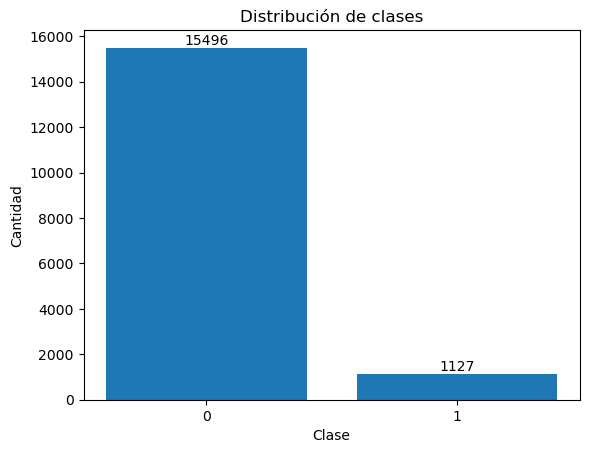

In [34]:
conteo = df_discurso_odio['class'].value_counts().sort_index()

bars = plt.bar(conteo.index.astype(str), conteo.values)

for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        int(altura),
        ha='center',
        va='bottom'
    )

plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.title('Distribución de clases')

plt.show()

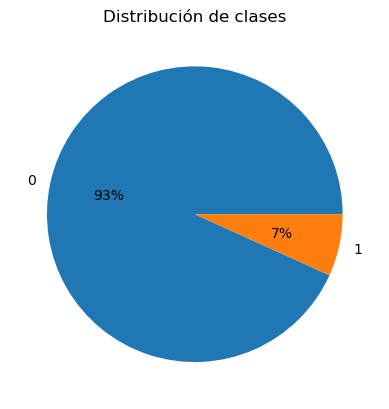

In [35]:
plt.pie(
    conteo.values,
    labels=conteo.index.astype(str),
    autopct='%1.0f%%'
)

plt.title('Distribución de clases')

plt.show()

### Los registros se separan en datos de prueba y entrenamiento

In [38]:
from sklearn.model_selection import train_test_split


X = df_discurso_odio['text']
y = df_discurso_odio['class']  # cambia por el nombre real de tu columna

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para prueba
    random_state=42,     # para reproducibilidad
    stratify=y
)

In [39]:
print(len(X_train), len(X_test))

13298 3325


#### **Procesamiento del texto**. (Falta realizar)

#### **Modelado con BETO**. (Falta realizar)

#### **Evaluacion del modelo**. (Falta realizar)
En esta etapa se realizo la evaluación del modelo mediante las siguientes métricas: 
- Tasa de error
- Accuracy (Exactitud)
- Recall (Sensibilidad)
- Especificidad 
- Precisión
- F-Score 

Y adicionalmente por el desbalance de datos en las clases se opto por emplear la siguiente métrica:
- Coeficiente de de Correlación de Matthews